|<div style="width:330px"><img src="https://www.ufz.de/static/custom/weblayout/DefaultInternetLayout/img/logos/ufz_transparent_de_blue.png" width="300"/></div>|<div style="width:290px"><img src="https://discourse.opengeosys.org/uploads/default/original/1X/a288c27cc8f73e6830ad98b8729637a260ce3490.png" width="290"/></div>|<div style="width:330px"><img src="https://github.com/nagelt/Teaching_Scripts/raw/9d9e29ecca4b04eaf7397938eacbf116d37ddc93/Images/TUBAF_Logo_blau.png" width="300"/></div>|
|---|---|--:|

Dr. Mehran Ghasabeh
\
Prof. Dr. Thomas Nagel

*Chair of Soil Mechanics and Foundation Engineering  
Geotechnical Institute  
Technische Universität Bergakademie Freiberg*

https://tu-freiberg.de/en/soilmechanics

# Tunnel Convergence Problem
## Solving Kirsch's Problem Using the Release Nodal Force Approach

### 1. Introduction

Tunnel excavation redistributes the in-situ stress and deforms the surrounding
rock. The inward movement of the excavation boundary is commonly called tunnel
convergence. Its magnitude depends on the initial stress, tunnel geometry,
constitutive behaviour, and any support traction acting on the wall.

This notebook models a circular opening in an infinite, homogeneous, isotropic,
linear-elastic medium under plane-strain conditions. Excavation is represented
by gradually withdrawing the traction that the removed material exerted on the
remaining rock. The final in-plane stresses are verified against the analytical
Kirsch solution [1], while the displacement history illustrates excavation-induced
convergence.

This notebook models a two-dimensional quarter section of a circular tunnel with a radius of $6.5\,\mathrm{m}$. A vertical compressive far-field stress of $20\,\mathrm{MPa}$ is applied, while symmetry boundary conditions are imposed along the left and bottom boundaries. The right boundary is traction-free, consistent with the uniaxial vertical far-field stress assumed for this verification benchmark.

Two modelling approaches are compared:

1. **Release nodal force approach:** the rock mass is initialized with an in-situ stress field, and the equivalent nodal forces acting at the tunnel wall are gradually released to represent excavation.
2. **Standard approach:** the tunnel is present from the beginning, and the external load is applied directly to an initially unstressed model.

Both approaches are evaluated using linear and quadratic finite elements. Stress
profiles are checked along the horizontal ($\theta=0^\circ$) and vertical
($\theta=90^\circ$) symmetry axes. OGS [2] uses the tension-positive sign
convention, so the applied compressive stress is $\sigma_\infty=-20\,\mathrm{MPa}$.
The finite numerical domain extends about 10.8 tunnel radii from the opening;
small far-field differences from the infinite-domain solution are therefore
expected.

**Learning objectives**

- configure a plane-strain `SMALL_DEFORMATION` process in OGS;
- understand compensation of the non-equilibrium initial residual;
- verify numerical stresses against the Kirsch solution; and
- distinguish element-order error, domain-truncation error, and nodal stress
  extrapolation effects.


#### **Release nodal force boundary condition**

This boundary condition applies a time-dependent *release nodal force* to the nodes of the boundary mesh on which it is defined, here the tunnel wall (`arc`). It is the numerical counterpart of the excavation process: instead of removing elements, the forces that the excavated material exerted on the remaining rock mass are gradually withdrawn.

##### Finite-element formulation

The small-deformation process solves the discrete equilibrium equations

$$
\boldsymbol{r}(\boldsymbol{u},t) \;=\; \boldsymbol{F}^{\mathrm{int}}(\boldsymbol{u}) - \boldsymbol{F}^{\mathrm{ext}}(t) \;=\; \boldsymbol{0},
\qquad
\boldsymbol{F}^{\mathrm{int}}(\boldsymbol{u}) \;=\; \int_{\Omega} \mathbf{B}^{\mathrm{T}}\,\boldsymbol{\sigma}\,\mathrm{d}\Omega ,
$$

where $\mathbf{B}$ is the strain–displacement matrix and $\boldsymbol{F}^{\mathrm{ext}}$ collects the applied loads (here the far-field traction on the top boundary). With the process initialized by the in-situ stress, the total stress is

$$
\boldsymbol{\sigma} \;=\; \boldsymbol{\sigma}_0 + \mathbb{C} : \boldsymbol{\varepsilon}(\boldsymbol{u}),
$$

with $\boldsymbol{\sigma}_0$ the in-situ stress and $\mathbb{C}$ the elasticity
tensor. For plane strain, $\varepsilon_{zz}=0$. Therefore the compatible
out-of-plane initial stress is
$\sigma_{0,zz}=\nu(\sigma_{0,xx}+\sigma_{0,yy})=-6\,\mathrm{MPa}$.

**Step 1 — non-equilibrium initial residual.** At $t=0$, with $\boldsymbol{u}_0 = \boldsymbol{0}$, the domain containing the (traction-free) opening is *not* in equilibrium under $\boldsymbol{\sigma}_0$. OGS assembles this initial out-of-balance force once:

$$
\boldsymbol{r}^{\mathrm{neq}}
\;=\; \boldsymbol{r}(\boldsymbol{u}_0, 0)
\;=\; \int_{\Omega} \mathbf{B}^{\mathrm{T}}\,\boldsymbol{\sigma}_0\,\mathrm{d}\Omega \;-\; \boldsymbol{F}^{\mathrm{ext}}(0).
$$

The vector $\boldsymbol{r}^{\mathrm{neq}}$ is called the **non-equilibrium initial residual**: the out-of-balance nodal force vector obtained by evaluating the equilibrium equations for the *undeformed* initial state. It is non-zero because a stress field that was in equilibrium in the intact ground is no longer in equilibrium in a domain containing the opening — at the traction-free tunnel wall nothing pushes back against $\boldsymbol{\sigma}_0$. Assembling $\int_\Omega \mathbf{B}^{\mathrm{T}}\boldsymbol{\sigma}_0\,\mathrm{d}\Omega$ node by node:

- at **interior nodes**, the contributions of neighbouring elements cancel — the entries vanish;
- at the **outer boundaries**, the internal forces are balanced by the applied
  top traction and by reactions at constrained symmetry degrees of freedom;
- at the **tunnel wall nodes**, nothing cancels them — the remaining entries are exactly the *equivalent nodal forces* that the excavated core exerted on the tunnel wall,

$$
F_{0,i} \;=\; r^{\mathrm{neq}}_i
\;=\; \int_{\Gamma_{\mathrm{arc}}} N_i \,\big(\boldsymbol{\sigma}_0\cdot\boldsymbol{n}\big)\,\mathrm{d}\Gamma ,
\qquad i \in \text{nodes of } \Gamma_{\mathrm{arc}},
$$

with $N_i$ the nodal shape function and $\boldsymbol{n}$ the outward normal of the wall. The `ReleaseNodalForce` boundary condition stores these values $F_{0,i}$ for every node of its boundary mesh. This step requires `<compensate_non_equilibrium_initial_residuum>true</compensate_non_equilibrium_initial_residuum>` on the process variable, since $\boldsymbol{r}^{\mathrm{neq}}$ is only computed (and kept) for compensated variables.

**Step 2 — compensation (in-situ equilibrium).** In every time step the solver subtracts the stored initial residual from the assembled one,

$$
\tilde{\boldsymbol{r}}(\boldsymbol{u},t) \;=\; \boldsymbol{r}(\boldsymbol{u},t) - \boldsymbol{r}^{\mathrm{neq}} ,
$$

so that at $t=0$ the model is exactly in equilibrium with $\boldsymbol{\sigma}_0$ and $\boldsymbol{u}=\boldsymbol{0}$: the compensation acts like a support force $\boldsymbol{F}_0$ that still holds the tunnel wall in place — the not-yet-excavated state.

**Step 3 — time-dependent release.** The boundary condition then adds, as a natural (Neumann-type) contribution at each wall degree of freedom $i$, the load

$$
b_i \;\mathrel{+}=\; -\big(1 - f(t)\big)\, F_{0,i} ,
$$

which, combined with Step 2, gives the effective residual at the wall nodes

$$
\tilde{r}_i(\boldsymbol{u},t)
\;=\; F^{\mathrm{int}}_i(\boldsymbol{u}) - F^{\mathrm{ext}}_i(t) - f(t)\,F_{0,i}
\;=\; 0 .
$$

The wall is therefore supported by the fictitious force $f(t)\,\boldsymbol{F}_0$, controlled by the user-defined *time-decay function* $f(t)$:

- at $t = 0$: $f = 1$, the full in-situ support acts, $\boldsymbol{u} = \boldsymbol{0}$ (no deformation);
- for $0 < t < t_\mathrm{e}$: partial release of the support-traction field
  $\boldsymbol{t}_\mathrm{support}(\theta,t)=
  f(t)\,\boldsymbol{\sigma}_0\boldsymbol{n}(\theta)$;
- at $t \ge t_\mathrm{e}$: $f = 0$, the wall is completely unloaded (traction-free) — the fully excavated, unsupported tunnel of the Kirsch problem.

##### Decay function used here

A linear decay over the excavation duration $t_\mathrm{e} = 2\,\mathrm{d} = 1.728\times 10^{5}\,\mathrm{s}$ is used:

$$
f(t) =
\begin{cases}
1 - \dfrac{t}{t_\mathrm{e}}, & 0 \le t \le t_\mathrm{e},\\[6pt]
0, & t > t_\mathrm{e}.
\end{cases}
$$

##### Project-file definition

In the project file, the boundary condition is defined on the process variable `displacement` as:

```xml
<boundary_condition>
    <mesh>arc</mesh>
    <type>ReleaseNodalForce</type>
    <time_decay_parameter>decay_function</time_decay_parameter>
</boundary_condition>
```

where `decay_function` is a `Function`-type parameter implementing $f(t)$ above.
Under the uniaxial initial stress used here this is a spatially varying vector
traction, not a uniform scalar pressure. The method requires `<initial_stress>`
and `compensate_non_equilibrium_initial_residuum`.


In [1]:
# Resolve the example directory when launched from JupyterLab or the repo root.
from pathlib import Path
import os
import sys

example_name = '01_Tunnel_Excavation_Kirsch'
example_dir = Path.cwd()
if not (example_dir / 'mesh_tunnel.py').is_file():
    example_dir = example_dir / example_name
if not example_dir.is_dir():
    raise FileNotFoundError(f"Example directory not found: {example_dir}")
os.chdir(example_dir)
if str(example_dir.resolve()) not in sys.path:
    sys.path.insert(0, str(example_dir.resolve()))
print(f"Example directory: {Path.cwd()}")


Example directory: /home/mehran/Desktop/OGS_Course_2026/01_Tunnel_Excavation_Kirsch


In [2]:
import os
from pathlib import Path
import shutil
import sys

import gmsh
import matplotlib.pyplot as plt
import numpy as np
import ogstools as ot
import pyvista as pv

# Keep paths independent of Windows/macOS syntax and Jupyter's launch directory.
# Set KIRSCH_PROJECT_ROOT only when the kernel starts outside this repository.
PROJECT_ROOT = Path(
    os.environ.get("KIRSCH_PROJECT_ROOT", Path.cwd())
).expanduser().resolve()
if not (PROJECT_ROOT / "mesh_tunnel.py").is_file():
    raise RuntimeError(
        "Project files were not found. Start Jupyter in the repository "
        "or set KIRSCH_PROJECT_ROOT to its full path."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def project_path(value):
    path = Path(value).expanduser()
    return path if path.is_absolute() else PROJECT_ROOT / path

from mesh_tunnel import MeshGenerator
from prj_tunnel import PrjGenerator

# --- Unified course plotting style (identical in all three course notebooks) ---
# Color identifies the entity (model, monitoring point, angle, time);
# linestyle identifies the solution type: simulation = solid (or markers
# for sampled points), analytical/reference = dashed (black if unambiguous).
# Continuous fields use the "jet" colormap.
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00",
             "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
CMAP_FIELD = "jet"
plt.rcParams.update({
    "font.size": 13,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
    "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=OKABE_ITO),
})

# --- Save every figure of this notebook as PDF to Outputs/ (identical in all
# three course notebooks). Figures are written automatically, either when
# they are shown (plt.show) or when the cell that created them finishes.
# Files are numbered in order of creation and named after the figure title;
# the folder is emptied each time this cell runs.
import re
from IPython import get_ipython

OUTPUT_DIR = Path("Outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
for _old_pdf in OUTPUT_DIR.glob("*.pdf"):
    _old_pdf.unlink()
_figure_count = 0


def _figure_name(fig):
    """File name stem from the figure title, or from the axis labels."""
    ax = fig.axes[0]
    candidates = [fig.get_suptitle(), *(a.get_title() for a in fig.axes),
                  f"{ax.get_ylabel()} vs {ax.get_xlabel()}"]
    text = next((t for t in candidates if t.strip(" vs")), "figure")
    text = re.sub(r"[\\$^{}]", "", text)
    return re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()[:60] or "figure"


def save_open_figures(*args):
    """Write all open matplotlib figures that were not saved yet to Outputs/."""
    global _figure_count
    for num in plt.get_fignums():
        fig = plt.figure(num)
        if fig.axes and not getattr(fig, "_saved_to_outputs", False):
            _figure_count += 1
            fig.savefig(OUTPUT_DIR / f"{_figure_count:02d}_{_figure_name(fig)}.pdf",
                        bbox_inches="tight")
            fig._saved_to_outputs = True


if not getattr(plt.show, "_saves_figures", False):
    _plt_show = plt.show

    def _show_and_save(*args, **kwargs):
        save_open_figures()
        return _plt_show(*args, **kwargs)

    _show_and_save._saves_figures = True
    plt.show = _show_and_save

if get_ipython() is not None:  # run before the inline backend closes figures
    _callbacks = get_ipython().events.callbacks["post_execute"]
    _callbacks[:] = [c for c in _callbacks if getattr(c, "__name__", "") != "save_open_figures"]
    _callbacks.insert(0, save_open_figures)


### 2. Model parameters

Physical and numerical parameters are defined here and passed explicitly to
the mesh and project generators. The absolute value of `TUNNEL_CENTER_Y` only
locates the mesh; gravity is disabled and the in-situ stress is prescribed.

In [3]:
# Kirsch benchmark parameters.
YOUNGS_MODULUS = 5.0e9  # Pa
POISSONS_RATIO = 0.30
VERTICAL_STRESS = 20.0e6  # Pa, positive magnitude
TUNNEL_RADIUS = 6.5  # m
TUNNEL_CENTER_X = 0.0  # m
TUNNEL_CENTER_Y = -857.0  # m
DOMAIN_EXTENT = 70.0  # m from each symmetry axis
INNER_BLOCK_EXTENT = 35.0  # m
MESH_TRANSITION_WIDTH = 5.0  # m outside the tunnel wall
EXCAVATION_DURATION = 1.728e5  # s (2 days)
END_TIME = 3.456e5  # s (4 days)

### 3. Solver settings

Nonlinear and linear solver configuration passed to
`PrjGenerator`. Change these to experiment with different
solvers without touching the model parameters above.

In [4]:
# Nonlinear solver (SMALL_DEFORMATION supports only Newton).
NONLINEAR_MAX_ITER = 10

# Linear solver: pick one preset by name.
LINEAR_SOLVER = "SparseLU"

LINEAR_SOLVER_PRESETS = {
    "BiCGSTAB + ILUT": {
        "linear_solver_type": "BiCGSTAB",
        "preconditioner_type": "ILUT",
        "linear_max_iter": 10000,
        "linear_error_tolerance": 1e-12,
        "linear_solver_scaling": False,
    },
    "BiCGSTAB + DIAGONAL": {
        "linear_solver_type": "BiCGSTAB",
        "preconditioner_type": "DIAGONAL",
        "linear_max_iter": 10000,
        "linear_error_tolerance": 1e-12,
        "linear_solver_scaling": False,
    },
    "CG + DIAGONAL": {
        "linear_solver_type": "CG",
        "preconditioner_type": "DIAGONAL",
        "linear_max_iter": 10000,
        "linear_error_tolerance": 1e-12,
        "linear_solver_scaling": False,
    },
    # Direct solver: no preconditioner/iterations; optional diagonal
    # scaling (needs an OGS build with Eigen unsupported modules).
    "SparseLU + scaling": {
        "linear_solver_type": "SparseLU",
        "preconditioner_type": None,
        "linear_max_iter": None,
        "linear_error_tolerance": None,
        "linear_solver_scaling": True,
    },
    "SparseLU": {
        "linear_solver_type": "SparseLU",
        "preconditioner_type": None,
        "linear_max_iter": None,
        "linear_error_tolerance": None,
        "linear_solver_scaling": False,
    },
}

linear_solver_options = LINEAR_SOLVER_PRESETS[LINEAR_SOLVER]
print(f"Linear solver: {LINEAR_SOLVER} -> {linear_solver_options}")

Linear solver: SparseLU -> {'linear_solver_type': 'SparseLU', 'preconditioner_type': None, 'linear_max_iter': None, 'linear_error_tolerance': None, 'linear_solver_scaling': False}


In [5]:
# Set this to True only when you intentionally want to erase all generated files.
reset_generated_folders = False

if reset_generated_folders:
    for folder in [project_path("_out"), project_path("_prj")]:
        if folder.is_dir():
            shutil.rmtree(folder)
            print(f"Deleted: {folder}")

In [6]:
out_dir = project_path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
if not out_dir.exists():
    out_dir.mkdir(parents=True)
    print(f"Created: {out_dir}")
mesh_dir_quad = project_path("input_meshes_quadratic")
mesh_dir_line = project_path("input_meshes_linear")
# create prj directory if it does not exist
prj_dir = project_path("_prj")
if not prj_dir.exists():
    prj_dir.mkdir(parents=True)
    print(f"Created: {prj_dir}")

### 4. Mesh generation

The same structured topology is generated with quadratic and linear elements.
Quadratic geometry represents the circular wall more accurately and also
improves extrapolated nodal stresses near the opening.

#### 4.1 Quadratic elements

In [7]:
if not gmsh.isInitialized():
    gmsh.initialize(readConfigFiles=False)
gmsh.model.add(mesh_dir_quad.name)
mesh_generator = MeshGenerator(
    gmsh_model=gmsh.model,
    tunnel_radius_i=TUNNEL_RADIUS,
    tunnel_radius_o=MESH_TRANSITION_WIDTH,
    tunnel_center_x=TUNNEL_CENTER_X,
    tunnel_center_y=TUNNEL_CENTER_Y,
    width=DOMAIN_EXTENT,
    height=DOMAIN_EXTENT,
    width_m=INNER_BLOCK_EXTENT,
    height_m=INNER_BLOCK_EXTENT,
)
mesh_generator.generate_meshes(out_dir=mesh_dir_quad, order=2)

gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 60%] Meshing curve 14 (Line)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 70%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Circle)
Info    : [ 80%] Meshing curve 18 (Circle)
Info    : [ 90%] Meshing curve 19 (Circle)
Info    : [ 90%] Meshing curve 20 (Circle)
Info    : [100%] Meshing curve 21 (Line)
Info    : [100%] Meshing curve 22 (Line)
Info    : Done meshing 1D (Wall 0.00119608s, CPU 0.001027s)
Info    : Meshi

INFO:ogstools.meshes.gmsh_converter:Detected domain dimension of 2


INFO:ogstools.meshes.gmsh_converter:Found material IDs: [1]


INFO:ogstools.meshes.gmsh_converter:Renumbered to: [0]


INFO:ogstools.meshes.gmsh_converter:domain: UnstructuredGrid (0x76d1c9993760)
  N Cells:    2800
  N Points:   2921
  X Bounds:   0.000e+00, 7.000e+01
  Y Bounds:   -8.570e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   1


...

INFO:ogstools.meshes.gmsh_converter:top: UnstructuredGrid (0x76d18f786200)
  N Cells:    40
  N Points:   41
  X Bounds:   0.000e+00, 7.000e+01
  Y Bounds:   -7.870e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2


INFO:ogstools.meshes.gmsh_converter:arc: UnstructuredGrid (0x76d18f786440)
  N Cells:    40
  N Points:   41
  X Bounds:   0.000e+00, 6.500e+00
  Y Bounds:   -8.570e+02, -8.505e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2


INFO:ogstools.meshes.gmsh_converter:Conversion complete.


domain: 2800 cells
bottom: 60 cells
left: 60 cells
right: 40 cells
top: 40 cells
arc: 40 cells
info: Reordering nodes... 
info: Method: Reversing order of nodes unless it is considered correct by the OGS6 standard, i.e. such that det(J) > 0, where J is the Jacobian of the global-to-local coordinate transformation.
info: Corrected 0 elements.
info: VTU file written.
Create quadratic mesh for /home/mehran/Desktop/OGS_Course_2026/01_Tunnel_Excavation_Kirsch/input_meshes_quadratic/bottom.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for /home/mehran/Desktop/OGS_Course_2026/01_Tunnel_Excavation_Kirsch/input_meshes_quadratic/arc.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for /home/mehran/Desktop/OGS_Course_2026/01_Tunnel_Excavation_Kirsch/input_meshes_quadratic/left.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for /home/mehran/Desktop

info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0158843 s
info: There is already a 'bulk_element_ids' property present in the subdomain mesh 'left' and it is equal to the newly computed values.
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 3.6373e-05 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0118183 s
info: There is already a 'bulk_element_ids' property present in the subdomain mesh 'right' and it is equal to the newly computed values.
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 3.101e-05 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0205285 s
info: There is already a 'bulk_element_ids' property present in the subdomain mesh 'top' and it is equal to the newly computed values.
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 3.9775e-05 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0150009 s
info: There is already a 'bulk_element_ids' property 

#### 4.2 Linear elements

In [8]:
if not gmsh.isInitialized():
    gmsh.initialize(readConfigFiles=False)
gmsh.model.add(mesh_dir_line.name)
mesh_generator = MeshGenerator(
    gmsh_model=gmsh.model,
    tunnel_radius_i=TUNNEL_RADIUS,
    tunnel_radius_o=MESH_TRANSITION_WIDTH,
    tunnel_center_x=TUNNEL_CENTER_X,
    tunnel_center_y=TUNNEL_CENTER_Y,
    width=DOMAIN_EXTENT,
    height=DOMAIN_EXTENT,
    width_m=INNER_BLOCK_EXTENT,
    height_m=INNER_BLOCK_EXTENT,
)
mesh_generator.generate_meshes(out_dir=mesh_dir_line, order=1)

gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 60%] Meshing curve 14 (Line)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 70%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Circle)
Info    : [ 80%] Meshing curve 18 (Circle)
Info    : [ 90%] Meshing curve 19 (Circle)
Info    : [ 90%] Meshing curve 20 (Circle)
Info    : [100%] Meshing curve 21 (Line)
Info    : [100%] Meshing curve 22 (Line)
Info    : Done meshing 1D (Wall 0.00229467s, CPU 0.001852s)
Info    : Meshi

INFO:ogstools.meshes.gmsh_converter:Detected domain dimension of 2


INFO:ogstools.meshes.gmsh_converter:Found material IDs: [1]


INFO:ogstools.meshes.gmsh_converter:Renumbered to: [0]


INFO:ogstools.meshes.gmsh_converter:domain: UnstructuredGrid (0x76d18f786440)
  N Cells:    2800
  N Points:   2921
  X Bounds:   0.000e+00, 7.000e+01
  Y Bounds:   -8.570e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   1


...

INFO:ogstools.meshes.gmsh_converter:top: UnstructuredGrid (0x76d18f786500)
  N Cells:    40
  N Points:   41
  X Bounds:   0.000e+00, 7.000e+01
  Y Bounds:   -7.870e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2


INFO:ogstools.meshes.gmsh_converter:arc: UnstructuredGrid (0x76d18f785c60)
  N Cells:    40
  N Points:   41
  X Bounds:   0.000e+00, 6.500e+00
  Y Bounds:   -8.570e+02, -8.505e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2


INFO:ogstools.meshes.gmsh_converter:Conversion complete.


domain: 2800 cells
bottom: 60 cells
left: 60 cells
right: 40 cells
top: 40 cells
arc: 40 cells
info: Reordering nodes... 
info: Method: Reversing order of nodes unless it is considered correct by the OGS6 standard, i.e. such that det(J) > 0, where J is the Jacobian of the global-to-local coordinate transformation.
info: Corrected 0 elements.
info: VTU file written.


info: Mesh reading time: 0.00948672 s
info: MeshNodeSearcher construction time: 0.000217091 s
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 0.000466073 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0108224 s
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 2.6284e-05 s
info: There is already a 'bulk_node_ids' property present in the subdomain mesh 'bottom' and it is equal to the newly computed values.
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.00536016 s
info: There is already a 'bulk_element_ids' property present in the subdomain mesh 'bottom' and it is equal to the newly computed values.
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 2.2143e-05 s
info: There is already a 'bulk_node_ids' property present in the subdomain mesh 'left' and it is equal to the newly computed values.
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.00595455 s
info: There is already a 'bulk_elem

In [9]:
kirsch_project_file = project_path("kirsch.prj")
prj_generator = PrjGenerator(
    mesh_dir=Path(),  # mesh files are selected through ot.Model / OGS -m
    element_order=2,
    youngs_modulus=YOUNGS_MODULUS,
    poissons_ratio=POISSONS_RATIO,
    vertical_stress=VERTICAL_STRESS,
    tunnel_radius=TUNNEL_RADIUS,
    tunnel_center_y=TUNNEL_CENTER_Y,
    excavation_duration=EXCAVATION_DURATION,
    end_time=END_TIME,
    nonlinear_max_iter=NONLINEAR_MAX_ITER,
    **linear_solver_options,
)
prj = prj_generator.generate_project(output_file=kirsch_project_file)

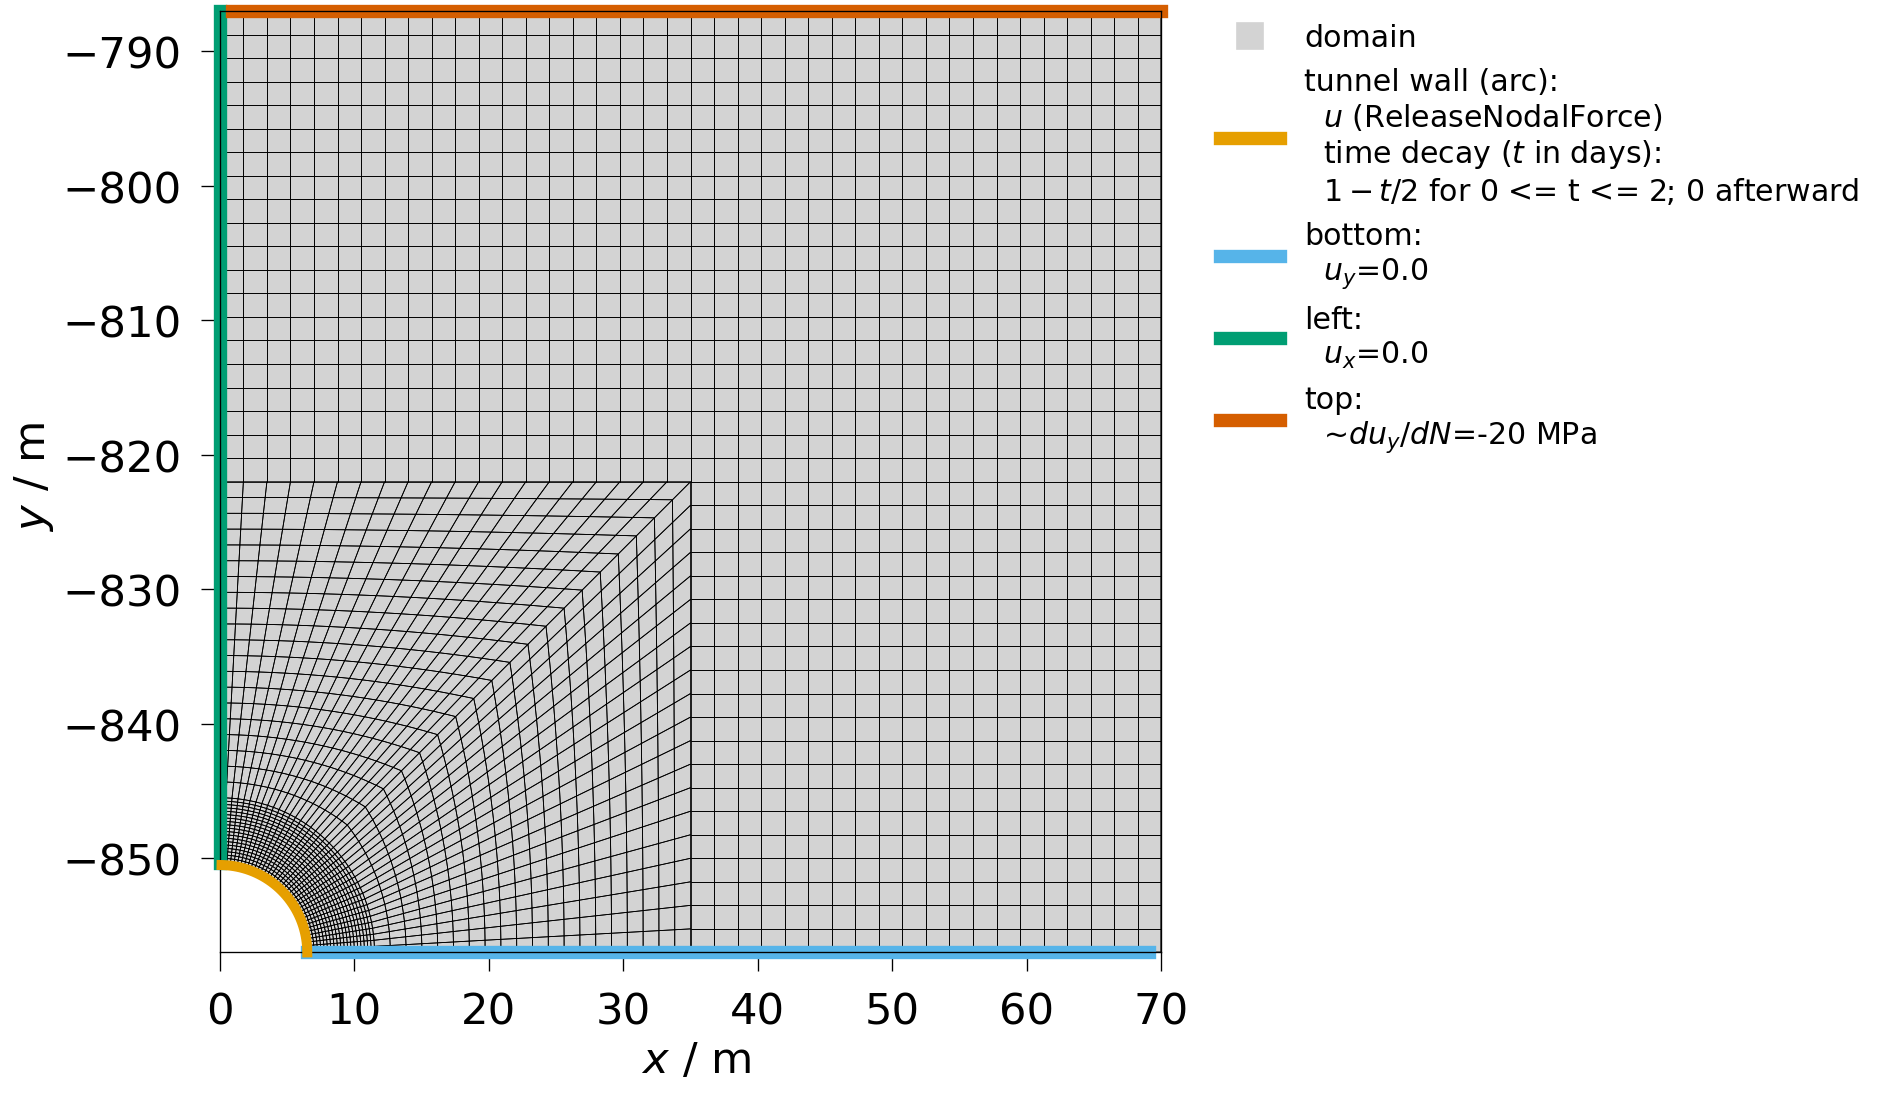

In [10]:
m = ot.Model(
    project=prj,
    meshes=mesh_dir_quad,
)

colors = {
    "arc": "#E69F00",
    "bottom": "#56B4E9",
    "left": "#009E73",
    "right": "#CC79A7",  # appears only if it has an explicit BC
    "top": "#D55E00",
}

fig = m.plot_constraints(figsize=(16, 9), fontsize=26, leg_fontsize=18)
ax = fig.axes[0]

# Change boundary colors and emphasize the tunnel wall.
for line in ax.lines:
    name = line.get_label().split(":", 1)[0]
    if name in colors:
        line.set_color(colors[name])
    if name == "arc":
        line.set_linewidth(6)
        line.set_zorder(10)

# Display the project values in engineering units in this figure.
excavation_duration_days = EXCAVATION_DURATION / (24 * 60 * 60)
vertical_stress_mpa = VERTICAL_STRESS / 1.0e6

# Change matching legend colors and replace the raw SI values.
legend = ax.get_legend()
for handle, text in zip(legend.legend_handles, legend.get_texts()):
    name = text.get_text().split(":", 1)[0]
    if name in colors:
        handle.set_color(colors[name])
    label = text.get_text()
    if name == "arc":
        label = (
            "tunnel wall (arc):\n"
            "  $u$ (ReleaseNodalForce)\n"
            "  time decay ($t$ in days):\n"
            f"  $1-t/{excavation_duration_days:g}$ for "
            f"0 <= t <= {excavation_duration_days:g}; "
            "0 afterward"
        )
    elif name == "top":
        label = label.replace(
            f"-{VERTICAL_STRESS}", f"-{vertical_stress_mpa:g} MPa"
        )
    text.set_text(label)

### 5. Computation

In [11]:
def runBenchmark(
    project_file,
    out_dir,
    prj_dir,
    output_prefix,
    mesh_dir,
    order=2,
    standard_approach=False,
    use_element_deactivation=False,
    ogs_path=None,
):
    prj = ot.Project(
        input_file=project_file,
        output_file=Path(prj_dir, f"{output_prefix}.prj"),
    )

    xpath_var = './process_variables/process_variable[name="displacement"]/'
    prj.replace_text(
        order,
        xpath=xpath_var + "order",
    )

    prj.replace_text(
        output_prefix,
        xpath="./time_loop/output/prefix",
    )

    if standard_approach:
        prj.replace_text(
            "false",
            xpath=xpath_var + "compensate_non_equilibrium_initial_residuum",
        )
        prj.remove_element(
            xpath=xpath_var + 'boundary_conditions/boundary_condition[mesh="arc"]'
        )
        prj.remove_element(xpath="./processes/process/initial_stress")
        prj.remove_element(xpath='./parameters/parameter[name="decay_function"]')

        prj.remove_element(xpath="./time_loop/processes/process/time_stepping")
        prj.time_loop.set_stepping(
            process="SD",
            type="FixedTimeStepping",
            t_initial="0",
            t_end="1",
            repeat="1",
            delta_t="1.0",
        )

    if use_element_deactivation:
        prj.add_block(
            blocktag="deactivated_subdomains",
            parent_xpath="./process_variables/process_variable",
        )
        prj.add_block(
            blocktag="deactivated_subdomain",
            parent_xpath="./process_variables/process_variable/deactivated_subdomains",
            taglist=["time_interval", "material_ids"],
            textlist=["", "1"],
        )
        prj.add_element(
            parent_xpath="./process_variables/process_variable/deactivated_subdomains/deactivated_subdomain/time_interval",
            tag="start",
            text="0",
        )
        prj.add_element(
            parent_xpath="./process_variables/process_variable/deactivated_subdomains/deactivated_subdomain/time_interval",
            tag="end",
            text="1e+18",
        )

    prj.write_input()

    # Prefer an explicit path, then the active environment, then PATH.
    # Windows uses ogs.exe; pathlib and shutil.which handle both separators.
    executable_name = "ogs.exe" if os.name == "nt" else "ogs"
    if ogs_path is not None:
        candidate = Path(ogs_path).expanduser()
        ogs_executable = candidate / executable_name if candidate.is_dir() else candidate
    else:
        environment_candidate = Path(sys.executable).parent / executable_name
        path_candidate = shutil.which(executable_name) or shutil.which("ogs")
        ogs_executable = (
            environment_candidate
            if environment_candidate.is_file()
            else Path(path_candidate) if path_candidate else environment_candidate
        )
    if not ogs_executable.is_file():
        raise FileNotFoundError(
            "OGS executable not found. Install it in the active environment, "
            "put it on PATH, or pass ogs_path to runBenchmark()."
        )

    execution = ot.Execution(
        ogs_path=str(ogs_executable.parent),
        omp_num_threads=4,
        ogs_asm_threads=4,
        write_logs=True,
    )

    model = ot.Model(project=prj, meshes=mesh_dir, execution=execution)
    simulation = model.run(
        target=Path(out_dir, output_prefix),
        overwrite=True,
    )

    print(f"Output prefix is {output_prefix}")
    print(f"OGS executable: {ogs_executable}")

    return simulation.meshseries_file

#### 5.1 Release nodal force approach

In [12]:
# This generated project contains the initial stress, arc release, and
# time-decay configuration used by the ReleaseNodalForce simulation.
release_project_file = kirsch_project_file
pvd = runBenchmark(
    project_file=release_project_file,
    out_dir=out_dir,
    prj_dir=prj_dir,
    output_prefix="kirsch",
    mesh_dir=mesh_dir_quad,
)

Output prefix is kirsch
OGS executable: /home/mehran/.venv313/bin/ogs


In [13]:
ms = ot.MeshSeries(pvd).scale(time="d")
ms_last = ms[-1]
xs = np.linspace(TUNNEL_RADIUS, DOMAIN_EXTENT, 35)
probes = np.c_[
    TUNNEL_CENTER_X + xs,
    np.full_like(xs, TUNNEL_CENTER_Y),
    np.zeros_like(xs),
]
extracted_ms = ot.MeshSeries.probe(ms, probes)

  0%|          | 0/22 [00:00<?, ?it/s]

 18%|█▊        | 4/22 [00:00<00:00, 29.42it/s]

 32%|███▏      | 7/22 [00:00<00:00, 25.02it/s]

 45%|████▌     | 10/22 [00:00<00:00, 23.71it/s]

 59%|█████▉    | 13/22 [00:00<00:00, 23.05it/s]

 73%|███████▎  | 16/22 [00:00<00:00, 22.70it/s]

 86%|████████▋ | 19/22 [00:00<00:00, 22.46it/s]

100%|██████████| 22/22 [00:00<00:00, 24.24it/s]

In [14]:
pvd_linear = runBenchmark(
    project_file=release_project_file,
    out_dir=out_dir,
    prj_dir=prj_dir,
    output_prefix="kirsch_linear_e",
    mesh_dir=mesh_dir_line,
    order=1,
)

Output prefix is kirsch_linear_e
OGS executable: /home/mehran/.venv313/bin/ogs


In [15]:
ms_linear = ot.MeshSeries(pvd_linear).scale(time="d")
extracted_ms_linear = ot.MeshSeries.probe(ms_linear, probes)

  0%|          | 0/22 [00:00<?, ?it/s]

 32%|███▏      | 7/22 [00:00<00:00, 62.32it/s]

 64%|██████▎   | 14/22 [00:00<00:00, 57.00it/s]

 91%|█████████ | 20/22 [00:00<00:00, 57.76it/s]

100%|██████████| 22/22 [00:00<00:00, 57.90it/s]

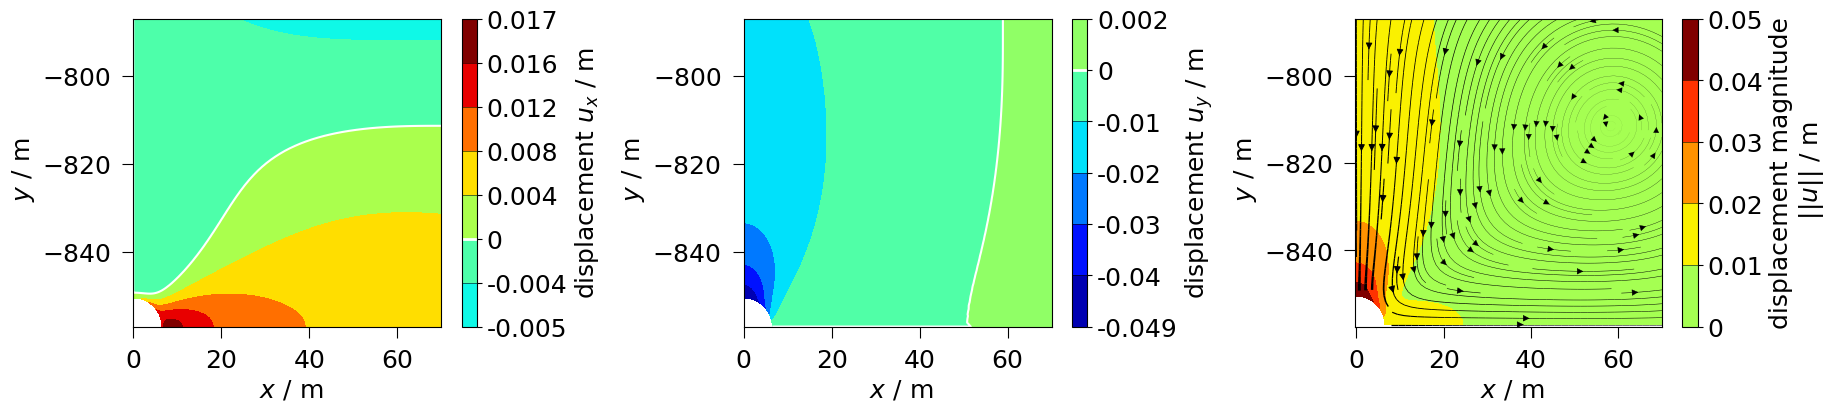

In [16]:
ot.plot.setup.num_levels = 6
displacement = ot.variables.displacement
fig, ax = plt.subplots(1, 3, figsize=(21, 4), gridspec_kw={"wspace": 0.5})
for axis, variable in zip(ax, [displacement["x"], displacement["y"], displacement]):
    ot.plot.contourf(
        ms_last,
        variable,
        fig=fig,
        ax=axis,
        fontsize=18,
        cb_labelsize=18,
        cmap=CMAP_FIELD,
    )

cb_length, cb_width = 1.0, 1.0  # fractions of the default colorbar size
for cax in [a for a in fig.axes if a.get_label() == "<colorbar>"]:
    p = cax.get_position()
    h = p.height * cb_length
    cax.set_position([p.x0, p.y0 + 0.5 * (p.height - h), p.width * cb_width, h])

plt.show()

The final stress state is shown as Cartesian and polar components. The stress
tensor is rotated into a polar coordinate system centred at the tunnel axis,

$$
\boldsymbol{\sigma}' \;=\; \mathbf{R}^{\mathrm{T}}\, \boldsymbol{\sigma}\, \mathbf{R},
$$

which is done directly by `ogstools` via `ot.variables.stress.to_polar(center=...)`; the radial and tangential components are then simply accessed as `["rr"]` and `["tt"]`.

The analytical traction condition gives $\sigma_{rr}=0$ at the wall.
Postprocessed OGS values are extrapolated from integration points to nodes, so
a small nonzero wall value is expected, especially for linear elements.

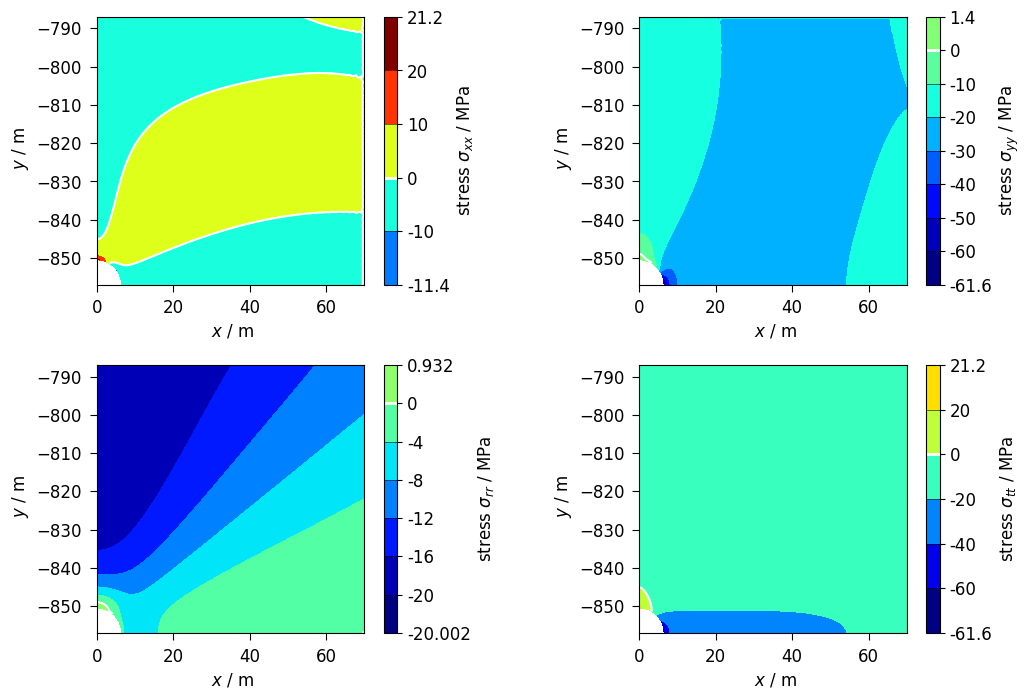

In [17]:
stress = ot.variables.stress
stress_polar = stress.to_polar(center=(TUNNEL_CENTER_X, TUNNEL_CENTER_Y, 0.0))

fig, ax = plt.subplots(
    2, 2, figsize=(12, 8), gridspec_kw={"wspace": 0.4, "hspace": 0.3}
)
variables = [stress["xx"], stress["yy"], stress_polar["rr"], stress_polar["tt"]]
for axis, variable in zip(ax.ravel(), variables):
    ot.plot.contourf(
        ms_last,
        variable,
        fig=fig,
        ax=axis,
        fontsize=12,
        cb_labelsize=12,
        cmap=CMAP_FIELD,
    )

fig.canvas.draw()  # finalize the axes positions before aligning colorbars
colorbar_axes = [
    axis for axis in fig.axes if axis.get_label() == "<colorbar>"
]
for plot_axis, colorbar_axis in zip(ax.ravel(), colorbar_axes):
    plot_pos = plot_axis.get_position()
    bar_pos = colorbar_axis.get_position()
    colorbar_axis.set_position(
        [bar_pos.x0, plot_pos.y0, bar_pos.width, plot_pos.height]
    )

plt.show()

For a frictional material such as rock, proximity to failure is governed by two invariants together: a deviatoric measure and the mean stress. The octahedral shear stress,

$$
\tau_\mathrm{oct} \;=\; \tfrac{1}{3}\sqrt{(\sigma_1-\sigma_2)^2 + (\sigma_2-\sigma_3)^2 + (\sigma_3-\sigma_1)^2}
\;=\; \sqrt{\tfrac{2}{3}\,J_2},
$$

is pressure-independent and shows where distortional (shear) loading concentrates, while the mean stress,

$$
\overline{\sigma} \;=\; \tfrac{1}{3}\,\mathrm{tr}\,\boldsymbol{\sigma},
$$

describes the hydrostatic part of the three-dimensional plane-strain stress
state. These invariants help interpret where excavation changes shear loading
and mean stress. They are diagnostic quantities only: assessing failure with
Mohr–Coulomb or Hoek–Brown would additionally require strength parameters and
a consistent compression-positive or tension-positive convention.

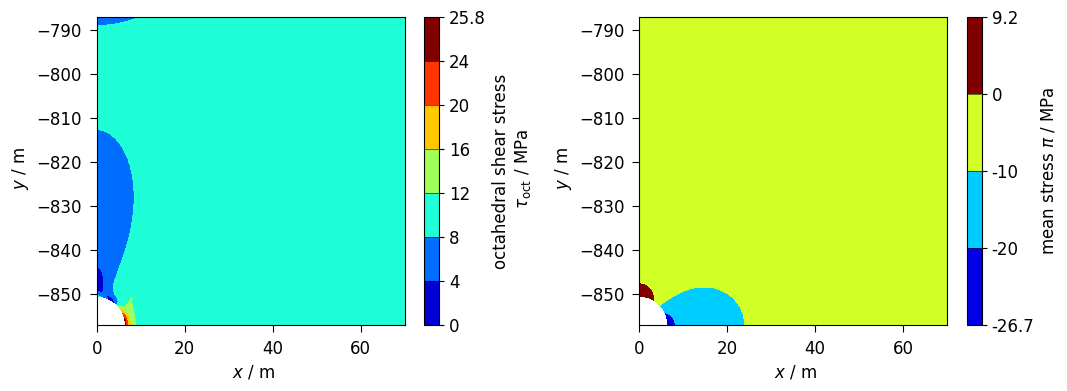

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"wspace": 0.4})
for axis, variable in zip(ax, [stress.octahedral_shear, stress.tensor_mean]):
    ot.plot.contourf(
        ms_last,
        variable,
        fig=fig,
        ax=axis,
        fontsize=12,
        cb_labelsize=12,
        cmap=CMAP_FIELD,
    )

fig.canvas.draw()  # finalize the axes positions before aligning colorbars
colorbar_axes = [
    axis for axis in fig.axes if axis.get_label() == "<colorbar>"
]
for plot_axis, colorbar_axis in zip(ax, colorbar_axes):
    plot_pos = plot_axis.get_position()
    bar_pos = colorbar_axis.get_position()
    colorbar_axis.set_position(
        [bar_pos.x0, plot_pos.y0, bar_pos.width, plot_pos.height]
    )

plt.show()

In addition to the contour maps, the polar stress components are shown radially, i.e. as profiles over the distance $r$ from the tunnel axis along the two symmetry lines $\theta = 0^\circ$ (horizontal) and $\theta = 90^\circ$ (vertical). They are compared with the full Kirsch solution [1] for a uniaxial far-field stress $\sigma_\infty$ acting in the vertical direction,

$$
\sigma_{rr}(r,\theta) \;=\; \frac{\sigma_\infty}{2}\left(1 - \frac{a^2}{r^2}\right)
- \frac{\sigma_\infty}{2}\left(1 - \frac{4a^2}{r^2} + \frac{3a^4}{r^4}\right)\cos 2\theta ,
$$

$$
\sigma_{\theta\theta}(r,\theta) \;=\; \frac{\sigma_\infty}{2}\left(1 + \frac{a^2}{r^2}\right)
+ \frac{\sigma_\infty}{2}\left(1 + \frac{3a^4}{r^4}\right)\cos 2\theta .
$$

The polar components are evaluated with `stress_polar.transform` on the 2D domain mesh (where `to_polar` performs the in-plane rotation) and then sampled along the two radial lines.

The Cartesian components $\sigma_{xx}$ and $\sigma_{yy}$ are shown in the first row, followed by the polar components $\sigma_{rr}$ and $\sigma_{\theta\theta}$ in the second row. On the two symmetry lines the shear component $\sigma_{r\theta}$ vanishes, so the Cartesian components coincide with the polar ones there: along $\theta = 0^\circ$, $\sigma_{xx} = \sigma_{rr}$ and $\sigma_{yy} = \sigma_{\theta\theta}$, while along $\theta = 90^\circ$ the roles are swapped.

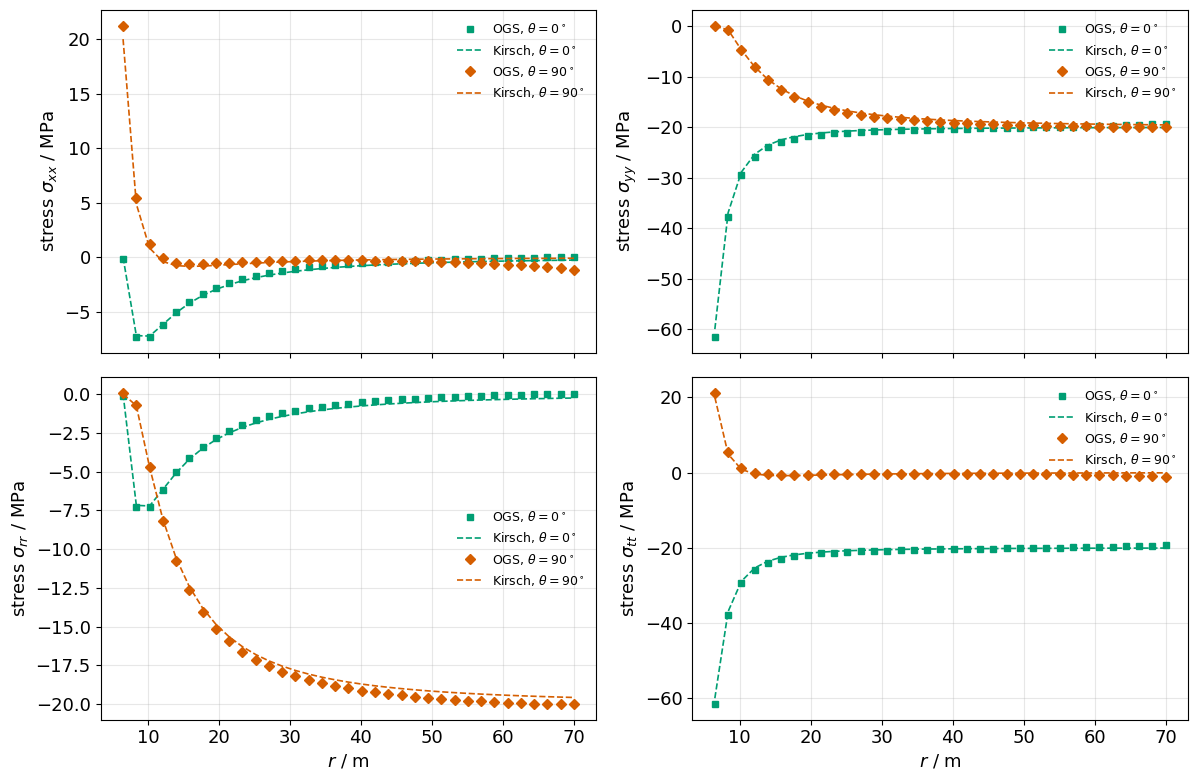

In [19]:
# Evaluate the polar stress components on the 2D mesh (values in MPa) and
# sample them along radial lines at theta = 0 and theta = 90 degrees.
ms_last.point_data["sigma_polar"] = stress_polar.transform(ms_last)

r_probe = np.linspace(TUNNEL_RADIUS, DOMAIN_EXTENT, 35)


def kirsch_polar(r, theta, s_far=-VERTICAL_STRESS / 1.0e6, a=TUNNEL_RADIUS):
    """Kirsch solution for a uniaxial far-field stress s_far in y-direction."""
    cos_2t = np.cos(2.0 * theta)
    sigma_rr = 0.5 * s_far * (1.0 - a**2 / r**2) - 0.5 * s_far * (
        1.0 - 4.0 * a**2 / r**2 + 3.0 * a**4 / r**4
    ) * cos_2t
    sigma_tt = 0.5 * s_far * (1.0 + a**2 / r**2) + 0.5 * s_far * (
        1.0 + 3.0 * a**4 / r**4
    ) * cos_2t
    return sigma_rr, sigma_tt


fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
variables = [
    ot.variables.stress["xx"],  # ax[0, 0]
    ot.variables.stress["yy"],  # ax[0, 1]
    stress_polar["rr"],  # ax[1, 0]
    stress_polar["tt"],  # ax[1, 1]
]
line_styles = [("0", 0.0, "C2", "s"), ("90", np.pi / 2, "C3", "D")]
for deg, theta, color, marker in line_styles:
    line_points = np.c_[
        TUNNEL_CENTER_X + r_probe * np.cos(theta),
        TUNNEL_CENTER_Y + r_probe * np.sin(theta),
        np.zeros_like(r_probe),
    ]
    line = pv.PolyData(line_points).sample(ms_last)
    sigma_rr_ana, sigma_tt_ana = kirsch_polar(r_probe, theta)
    numerical = [
        line["sigma"][:, 0] / 1.0e6,
        line["sigma"][:, 1] / 1.0e6,
        line["sigma_polar"][:, 0],
        line["sigma_polar"][:, 1],
    ]
    # On the symmetry lines sigma_rt = 0, so the Cartesian components
    # coincide with the polar ones (swapped on the vertical line).
    if theta == 0.0:
        analytical = [sigma_rr_ana, sigma_tt_ana, sigma_rr_ana, sigma_tt_ana]
    else:
        analytical = [sigma_tt_ana, sigma_rr_ana, sigma_rr_ana, sigma_tt_ana]
    for axis, num, ana in zip(ax.ravel(), numerical, analytical):
        axis.plot(
            r_probe,
            num,
            marker=marker,
            markersize=5,
            linestyle="None",
            color=color,
            label=rf"OGS, $\theta = {deg}^\circ$",
        )
        axis.plot(
            r_probe,
            ana,
            linewidth=1.2,
            linestyle="--",
            color=color,
            label=rf"Kirsch, $\theta = {deg}^\circ$",
        )

for axis, variable in zip(ax.ravel(), variables):
    axis.set_ylabel(variable.get_label())
    axis.grid(True)
    axis.legend(fontsize=9)
for axis in ax[1]:
    axis.set_xlabel("$r$ / m")

fig.tight_layout()
plt.show()

#### 5.2 Standard approach

In [20]:
pvd_std = runBenchmark(
    project_file=release_project_file,
    out_dir=out_dir,
    prj_dir=prj_dir,
    output_prefix="kirsch_standard",
    mesh_dir=mesh_dir_quad,
    order=2,
    standard_approach=True,
)

Output prefix is kirsch_standard
OGS executable: /home/mehran/.venv313/bin/ogs


In [21]:
ms_std = ot.MeshSeries(pvd_std).scale(time="d")
extracted_ms_std = ot.MeshSeries.probe(ms_std, probes)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 37.15it/s]

In [22]:
pvd_std_linear = runBenchmark(
    project_file=release_project_file,
    out_dir=out_dir,
    prj_dir=prj_dir,
    output_prefix="kirsch_standard_linear",
    mesh_dir=mesh_dir_line,
    order=1,
    standard_approach=True,
)

Output prefix is kirsch_standard_linear
OGS executable: /home/mehran/.venv313/bin/ogs


In [23]:
ms_std_linear = ot.MeshSeries(pvd_std_linear).scale(time="d")
extracted_ms_std_linear = ot.MeshSeries.probe(ms_std_linear, probes)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 71.79it/s]

#### 5.3 Automated verification checks

The release and standard formulations must produce the same final total stress.
Their displacement fields are not compared directly: the release model uses the
in-situ state as its zero-displacement reference, whereas the standard model also
contains deformation caused by applying the far-field load. In addition, both
element orders are checked quantitatively against the analytical Kirsch profiles.
The wall node and the outermost 20% of the domain are excluded from that check to
avoid mixing nodal stress-extrapolation and finite-boundary effects into the
discretization error measure.

In [24]:
def max_stress_difference_mpa(release_series, standard_series):
    difference = release_series[-1].point_data["sigma"] - standard_series[-1].point_data["sigma"]
    return np.max(np.abs(difference)) / 1.0e6


quadratic_stress_difference = max_stress_difference_mpa(ms, ms_std)
linear_stress_difference = max_stress_difference_mpa(ms_linear, ms_std_linear)
initial_displacement = np.max(np.abs(ms[0].point_data["displacement"]))
displacement_reference_difference = np.max(
    np.abs(ms[-1].point_data["displacement"] - ms_std[-1].point_data["displacement"])
)

np.testing.assert_allclose(
    ms[-1].point_data["sigma"],
    ms_std[-1].point_data["sigma"],
    rtol=1.0e-10,
    atol=1.0e-3,
)
np.testing.assert_allclose(
    ms_linear[-1].point_data["sigma"],
    ms_std_linear[-1].point_data["sigma"],
    rtol=1.0e-10,
    atol=1.0e-3,
)
assert initial_displacement < 1.0e-12

wall_rr_quadratic = extracted_ms[-1].point_data["sigma"][0, 0] / 1.0e6
wall_rr_linear = extracted_ms_linear[-1].point_data["sigma"][0, 0] / 1.0e6
print(f"Maximum final stress difference, quadratic: {quadratic_stress_difference:.3e} MPa")
print(f"Maximum final stress difference, linear:    {linear_stress_difference:.3e} MPa")
print(f"Maximum initial displacement:               {initial_displacement:.3e} m")
print(f"Expected displacement-reference difference: {displacement_reference_difference:.4f} m")
print(f"Wall sigma_rr, quadratic:                   {wall_rr_quadratic:.3f} MPa")
print(f"Wall sigma_rr, linear:                      {wall_rr_linear:.3f} MPa")

# Probe the vertical symmetry axis as well as the horizontal axis already used
# above. On these axes the Cartesian normal stresses equal the radial and
# tangential stresses, with their roles swapped on the vertical axis.
r_vertical = xs.copy()
ys = TUNNEL_CENTER_Y + r_vertical
y_axis = np.c_[
    np.full_like(ys, TUNNEL_CENTER_X),
    ys,
    np.zeros_like(ys),
]
extracted_ms_y = ot.MeshSeries.probe(ms, y_axis)
extracted_ms_y_linear = ot.MeshSeries.probe(ms_linear, y_axis)


def kirsch_profile_errors(horizontal, vertical):
    """Return far-field-normalized L-infinity and RMSE profile errors."""
    sigma_x = horizontal[-1].point_data["sigma"] / 1.0e6
    sigma_y = vertical[-1].point_data["sigma"] / 1.0e6
    rr_0, tt_0 = kirsch_polar(xs, 0.0)
    rr_90, tt_90 = kirsch_polar(r_vertical, np.pi / 2)

    # Exclude the extrapolated wall node and the outermost 20% of the domain,
    # where the finite square boundary differs from the infinite Kirsch domain.
    verification_region = (xs > TUNNEL_RADIUS) & (xs <= 0.8 * DOMAIN_EXTENT)
    profile_pairs = [
        (sigma_x[:, 0], rr_0),
        (sigma_x[:, 1], tt_0),
        (sigma_y[:, 1], rr_90),
        (sigma_y[:, 0], tt_90),
    ]
    errors = np.concatenate(
        [
            numerical[verification_region] - analytical[verification_region]
            for numerical, analytical in profile_pairs
        ]
    )
    stress_scale = VERTICAL_STRESS / 1.0e6
    normalized_linf = np.max(np.abs(errors)) / stress_scale
    normalized_rmse = np.sqrt(np.mean(errors**2)) / stress_scale
    return normalized_linf, normalized_rmse


kirsch_errors = {
    "quadratic": kirsch_profile_errors(extracted_ms, extracted_ms_y),
    "linear": kirsch_profile_errors(extracted_ms_linear, extracted_ms_y_linear),
}
for element_order, (normalized_linf, normalized_rmse) in kirsch_errors.items():
    print(
        f"Kirsch error, {element_order:9s}: "
        f"L_inf={normalized_linf:.2%}, RMSE={normalized_rmse:.2%}"
    )
    assert normalized_linf < 0.06
    assert normalized_rmse < 0.025


Maximum final stress difference, quadratic: 9.474e-11 MPa
Maximum final stress difference, linear:    4.567e-12 MPa
Maximum initial displacement:               0.000e+00 m
Expected displacement-reference difference: 0.2548 m
Wall sigma_rr, quadratic:                   -0.133 MPa
Wall sigma_rr, linear:                      -2.620 MPa


Kirsch error, quadratic: L_inf=4.08%, RMSE=1.39%
Kirsch error, linear   : L_inf=3.95%, RMSE=1.40%


### 6. Verification and result comparison

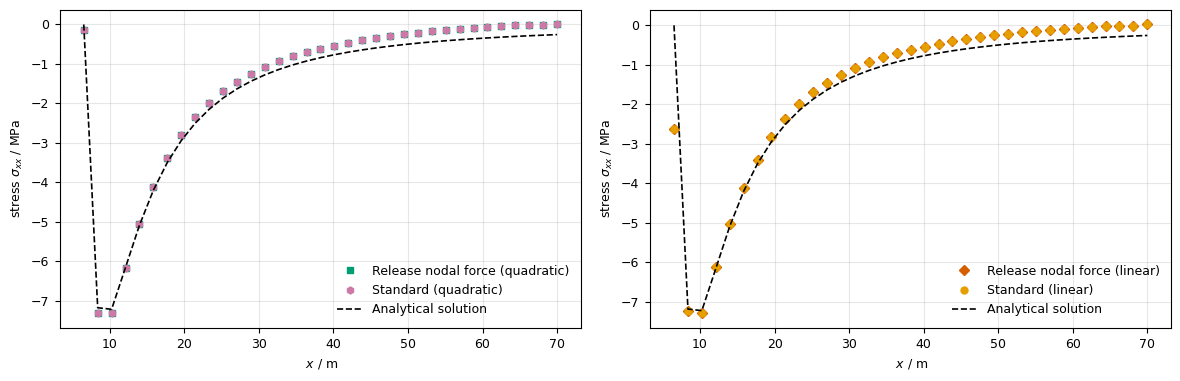

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
series = [
    (extracted_ms[-1], ax[0], "C2", "s", "Release nodal force (quadratic)"),
    (extracted_ms_std[-1], ax[0], "C4", "h", "Standard (quadratic)"),
    (extracted_ms_linear[-1], ax[1], "C3", "D", "Release nodal force (linear)"),
    (extracted_ms_std_linear[-1], ax[1], "C1", "o", "Standard (linear)"),
]
for line_mesh, axis, color, marker, label in series:
    ot.plot.lineplots.line(
        line_mesh,
        ot.variables.stress["xx"],
        ax=axis,
        fontsize=9,
        grid=False,
        marker=marker,
        markersize=5,
        linestyle="None",
        color=color,
        label=label,
    )

# Kirsch solution: sigma_xx = sigma_rr along theta = 0.
sigma_analytical = kirsch_polar(xs, 0.0)[0]
for axis in ax:
    axis.plot(
        xs,
        sigma_analytical,
        linewidth=1.2,
        linestyle="--",
        color="black",
        label="Analytical solution",
    )
    axis.grid(True)
    axis.legend(fontsize=9)
plt.show()

The release and standard approaches coincide for both element orders. At the
wall the analytical radial stress is zero. The quadratic extrapolated value is
about $-0.13\,\mathrm{MPa}$, while the linear value is about
$-2.62\,\mathrm{MPa}$ for this mesh. This is a nodal stress-extrapolation and
discretization error, not a violation of the imposed traction condition at the
integration level.

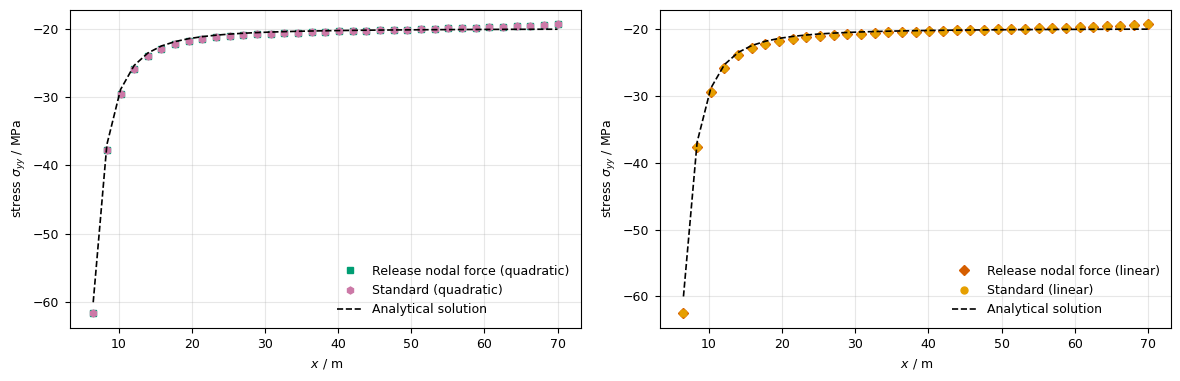

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
series = [
    (extracted_ms[-1], ax[0], "C2", "s", "Release nodal force (quadratic)"),
    (extracted_ms_std[-1], ax[0], "C4", "h", "Standard (quadratic)"),
    (extracted_ms_linear[-1], ax[1], "C3", "D", "Release nodal force (linear)"),
    (extracted_ms_std_linear[-1], ax[1], "C1", "o", "Standard (linear)"),
]
for line_mesh, axis, color, marker, label in series:
    ot.plot.lineplots.line(
        line_mesh,
        ot.variables.stress["yy"],
        ax=axis,
        fontsize=9,
        grid=False,
        marker=marker,
        markersize=5,
        linestyle="None",
        color=color,
        label=label,
    )

# Kirsch solution: sigma_yy = sigma_tt along theta = 0.
sigma_analytical = kirsch_polar(xs, 0.0)[1]
for axis in ax:
    axis.plot(
        xs,
        sigma_analytical,
        linewidth=1.2,
        linestyle="--",
        color="black",
        label="Analytical solution",
    )
    axis.grid(True)
    axis.legend(fontsize=9)
plt.show()

The tangential stress concentration is captured well by both formulations.
Quadratic elements give the more accurate extrapolated wall value. Differences
near the outer boundary are caused mainly by replacing the infinite domain with
a finite square boundary.

In [27]:
r_vertical = np.linspace(TUNNEL_RADIUS, DOMAIN_EXTENT, 35)
ys = TUNNEL_CENTER_Y + r_vertical
y_axis = np.c_[
    np.full_like(ys, TUNNEL_CENTER_X),
    ys,
    np.zeros_like(ys),
]
extracted_ms_y = ot.MeshSeries.probe(ms, y_axis)
extracted_ms_y_linear = ot.MeshSeries.probe(ms_linear, y_axis)
extracted_ms_std_y = ot.MeshSeries.probe(ms_std, y_axis)
extracted_ms_std_y_linear = ot.MeshSeries.probe(ms_std_linear, y_axis)

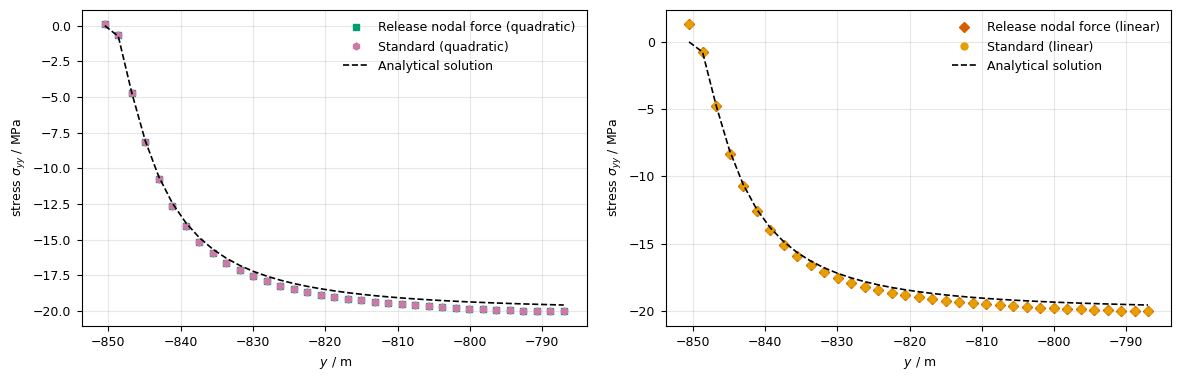

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
series = [
    (extracted_ms_y[-1], ax[0], "C2", "s", "Release nodal force (quadratic)"),
    (extracted_ms_std_y[-1], ax[0], "C4", "h", "Standard (quadratic)"),
    (extracted_ms_y_linear[-1], ax[1], "C3", "D", "Release nodal force (linear)"),
    (extracted_ms_std_y_linear[-1], ax[1], "C1", "o", "Standard (linear)"),
]
for line_mesh, axis, color, marker, label in series:
    ot.plot.lineplots.line(
        line_mesh,
        ot.variables.stress["yy"],
        ax=axis,
        fontsize=9,
        grid=False,
        marker=marker,
        markersize=5,
        linestyle="None",
        color=color,
        label=label,
    )

# Kirsch solution: sigma_yy = sigma_rr along theta = 90.
sigma_analytical = kirsch_polar(r_vertical, np.pi / 2)[0]
for axis in ax:
    axis.plot(
        ys,
        sigma_analytical,
        linewidth=1.2,
        linestyle="--",
        color="black",
        label="Analytical solution",
    )
    axis.grid(True)
    axis.legend(fontsize=9)
plt.show()

In the two figures above, the radial stress $\sigma_r$ profiles along the $\theta = 90^\circ$ axis are similarly compared across the standard approach, the release nodal force approach, and the analytical solution. The same conclusion as above can be drawn.

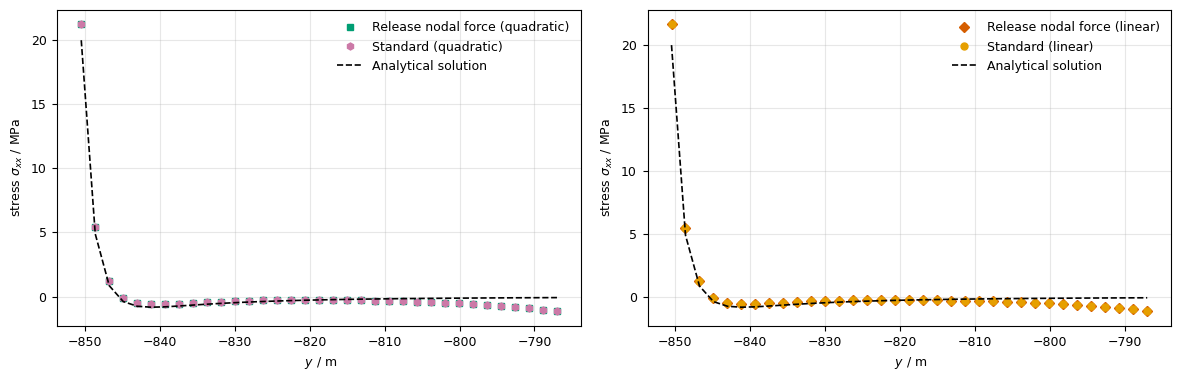

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
series = [
    (extracted_ms_y[-1], ax[0], "C2", "s", "Release nodal force (quadratic)"),
    (extracted_ms_std_y[-1], ax[0], "C4", "h", "Standard (quadratic)"),
    (extracted_ms_y_linear[-1], ax[1], "C3", "D", "Release nodal force (linear)"),
    (extracted_ms_std_y_linear[-1], ax[1], "C1", "o", "Standard (linear)"),
]
for line_mesh, axis, color, marker, label in series:
    ot.plot.lineplots.line(
        line_mesh,
        ot.variables.stress["xx"],
        ax=axis,
        fontsize=9,
        grid=False,
        marker=marker,
        markersize=5,
        linestyle="None",
        color=color,
        label=label,
    )

# Kirsch solution: sigma_xx = sigma_tt along theta = 90.
sigma_analytical = kirsch_polar(r_vertical, np.pi / 2)[1]
for axis in ax:
    axis.plot(
        ys,
        sigma_analytical,
        linewidth=1.2,
        linestyle="--",
        color="black",
        label="Analytical solution",
    )
    axis.grid(True)
    axis.legend(fontsize=9)
plt.show()

In the two figures above, the tangential stress $\sigma_{\theta}$ profiles along the $\theta = 90^\circ$ axis—obtained using the standard approach, the release nodal force approach, and the analytical solution—are compared. The figure on the right shows results using linear elements, while the figure on the left displays results using quadratic elements.

The figures show that the quadratic elements deliver more accurate tangential stress results than the linear elements do.

In [30]:
history_radii = TUNNEL_RADIUS + np.array([0.0, 1.0, 2.5, 3.5, 8.5])
spoints = np.c_[
    np.full_like(history_radii, TUNNEL_CENTER_X),
    TUNNEL_CENTER_Y + history_radii,
    np.zeros_like(history_radii),
]
labels = [f"r = {radius:.1f} m" for radius in history_radii]

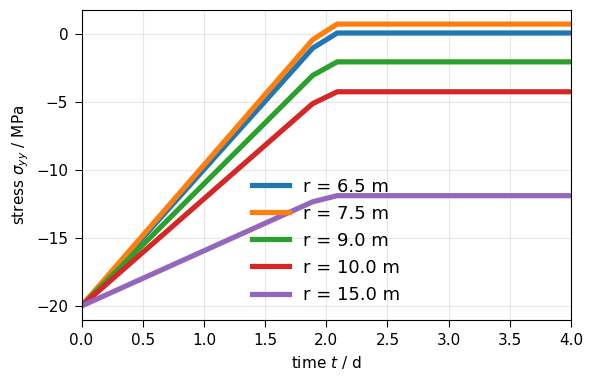

In [31]:
extracted_sp = ot.MeshSeries.probe(ms, spoints)
ot.plot.line(
    extracted_sp,
    "time",
    ot.variables.stress["yy"],
    labels=labels,
    figsize=(6, 4),
    fontsize=11,
    grid=False,
    linewidth=1.5,
)
plt.xlim(0, 4)
plt.legend()

plt.grid(True)
plt.show()

The figure shows radial stress along the vertical symmetry line
($\theta=90^\circ$). At the wall it evolves from the initial compressive
stress toward the traction-free value as the support traction is released. The
response becomes constant after the two-day excavation interval.

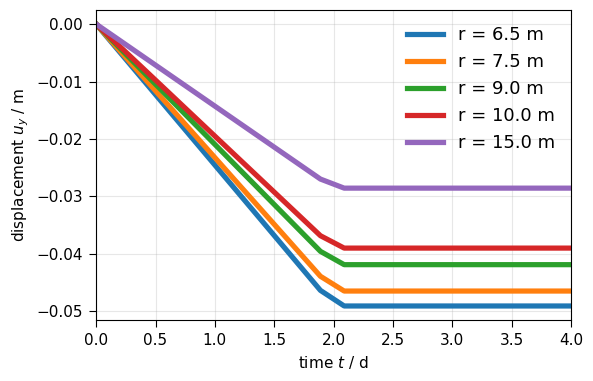

In [32]:
ot.plot.line(
    extracted_sp,
    "time",
    ot.variables.displacement["y"],
    labels=labels,
    figsize=(6, 4),
    fontsize=11,
    grid=False,
    linewidth=1.5,
)
plt.xlim(0, 4)
plt.legend()

plt.grid(True)
plt.show()

Along $\theta=90^\circ$, the $y$ displacement is radial. Its magnitude grows
during unloading and then remains constant. These displacements are measured
relative to the initially stressed in-situ state, which is why they should not
be compared directly with the standard model's total displacement.

### 7. Element-deactivation representation

The alternative mesh contains a quarter-disc inside the opening. Those elements
(material ID 1) are inactive for the entire simulation; this is a representation
check, not a staged active-to-inactive excavation. OGS writes zero stress for the
inactive cells. At nodes shared by active and inactive cells, nodal stress
extrapolation therefore mixes physical rock stresses with zeros. Exact wall-node
stresses from this mesh must not be used for verification. The comparison below
excludes that shared node and evaluates the active rock away from the interface.

In [33]:
if not gmsh.isInitialized():
    gmsh.initialize(readConfigFiles=False)

gmsh.model.add("Mesh_with_inactive_cavern")
mesh_generator = MeshGenerator(
    gmsh_model=gmsh.model,
    tunnel_radius_i=TUNNEL_RADIUS,
    tunnel_radius_o=MESH_TRANSITION_WIDTH,
    tunnel_center_x=TUNNEL_CENTER_X,
    tunnel_center_y=TUNNEL_CENTER_Y,
    width=DOMAIN_EXTENT,
    height=DOMAIN_EXTENT,
    width_m=INNER_BLOCK_EXTENT,
    height_m=INNER_BLOCK_EXTENT,
)
mesh_dir_with_hole = Path(out_dir, "Mesh", "Entire")
mesh_generator.generate_meshes(out_dir=mesh_dir_with_hole, with_cavern=True, order=2)

gmsh.finalize()

INFO:ogstools.meshes.gmsh_converter:Detected domain dimension of 2


INFO:ogstools.meshes.gmsh_converter:Found material IDs: [1 2]


INFO:ogstools.meshes.gmsh_converter:Renumbered to: [0 1]


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 60%] Meshing curve 14 (Line)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 70%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Circle)
Info    : [ 80%] Meshing curve 18 (Circle)
Info    : [ 90%] Meshing curve 19 (Circle)
Info    : [ 90%] Meshing curve 20 (Circle)
Info    : [100%] Meshing curve 21 (Line)
Info    : [100%] Meshing curve 22 (Line)
Info    : Done meshing 1D (Wall 0.00090848s, CPU 0.001426s)
Info    : Meshi

INFO:ogstools.meshes.gmsh_converter:domain: UnstructuredGrid (0x76d183c4d9c0)
  N Cells:    3148
  N Points:   3082
  X Bounds:   0.000e+00, 7.000e+01
  Y Bounds:   -8.570e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   1


...

INFO:ogstools.meshes.gmsh_converter:cavern: UnstructuredGrid (0x76d183c40460)
  N Cells:    348
  N Points:   202
  X Bounds:   0.000e+00, 6.500e+00
  Y Bounds:   -8.570e+02, -8.505e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2


INFO:ogstools.meshes.gmsh_converter:Conversion complete.


domain: 3148 cells
bottom: 67 cells
left: 67 cells
right: 40 cells
top: 40 cells
arc: 40 cells
cavern: 348 cells
info: Reordering nodes... 
info: Method: Reversing order of nodes unless it is considered correct by the OGS6 standard, i.e. such that det(J) > 0, where J is the Jacobian of the global-to-local coordinate transformation.
info: Corrected 0 elements.
info: VTU file written.
Create quadratic mesh for /home/mehran/Desktop/OGS_Course_2026/01_Tunnel_Excavation_Kirsch/_out/Mesh/Entire/arc.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for /home/mehran/Desktop/OGS_Course_2026/01_Tunnel_Excavation_Kirsch/_out/Mesh/Entire/top.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for /home/mehran/Desktop/OGS_Course_2026/01_Tunnel_Excavation_Kirsch/_out/Mesh/Entire/left.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for /home/mehran/Desktop/OG

info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for /home/mehran/Desktop/OGS_Course_2026/01_Tunnel_Excavation_Kirsch/_out/Mesh/Entire/domain.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
info: Mesh reading time: 0.0176962 s
info: MeshNodeSearcher construction time: 0.00075052 s
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 0.00148368 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0268872 s
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 0.000124109 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0171453 s
info: There is already a 'bulk_element_ids' property present in the subdomain mesh 'bottom' and it is equal to the newly computed values.
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 0.000112381 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0144493 s
info: There is already a 'bulk_element_ids'

info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0112647 s
info: There is already a 'bulk_element_ids' property present in the subdomain mesh 'cavern' and it is equal to the newly computed values.
info: identifySubdomains time: 0.109989 s
info: writing time: 0.0336567 s
info: Entire run time: 0.162605 s


In [34]:
pvd_ed = runBenchmark(
    project_file=release_project_file,
    out_dir=out_dir,
    prj_dir=prj_dir,
    output_prefix="kirsch_element_deactivation",
    mesh_dir=mesh_dir_with_hole,
    order=2,
    use_element_deactivation=True,
)

Output prefix is kirsch_element_deactivation
OGS executable: /home/mehran/.venv313/bin/ogs


In [35]:
ms_ed = ot.MeshSeries(pvd_ed).scale(time="d")
extracted_ms_ed_x = ot.MeshSeries.probe(ms_ed, probes)
extracted_ms_ed_y = ot.MeshSeries.probe(ms_ed, y_axis)

  0%|          | 0/22 [00:00<?, ?it/s]

 14%|█▎        | 3/22 [00:00<00:00, 26.89it/s]

 27%|██▋       | 6/22 [00:00<00:00, 22.08it/s]

 41%|████      | 9/22 [00:00<00:00, 20.41it/s]

 55%|█████▍    | 12/22 [00:00<00:00, 20.60it/s]

 68%|██████▊   | 15/22 [00:00<00:00, 19.83it/s]

 82%|████████▏ | 18/22 [00:00<00:00, 20.25it/s]

 95%|█████████▌| 21/22 [00:01<00:00, 20.46it/s]

100%|██████████| 22/22 [00:01<00:00, 20.47it/s]

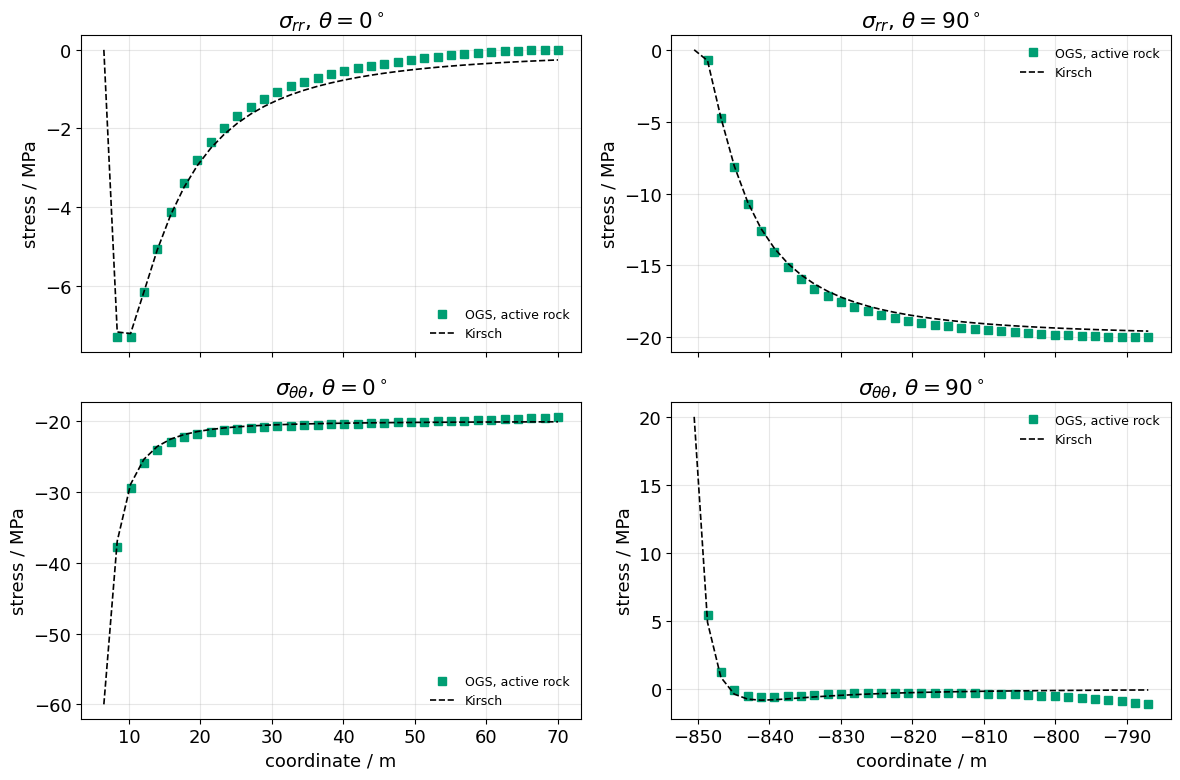

In [36]:
# Skip index 0: it is the node shared by active and inactive elements.
rock_slice = slice(1, None)
ed_x = extracted_ms_ed_x[-1].point_data["sigma"] / 1.0e6
ed_y = extracted_ms_ed_y[-1].point_data["sigma"] / 1.0e6
release_x = extracted_ms[-1].point_data["sigma"] / 1.0e6
release_y = extracted_ms_y[-1].point_data["sigma"] / 1.0e6

np.testing.assert_allclose(ed_x[rock_slice, :2], release_x[rock_slice, :2], atol=1.0e-8)
np.testing.assert_allclose(ed_y[rock_slice, :2], release_y[rock_slice, :2], atol=1.0e-8)

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex="col")
profiles = [
    (xs, ed_x[:, 0], kirsch_polar(xs, 0.0)[0], r"$\sigma_{rr}$, $\theta=0^\circ$"),
    (ys, ed_y[:, 1], kirsch_polar(r_vertical, np.pi / 2)[0], r"$\sigma_{rr}$, $\theta=90^\circ$"),
    (xs, ed_x[:, 1], kirsch_polar(xs, 0.0)[1], r"$\sigma_{\theta\theta}$, $\theta=0^\circ$"),
    (ys, ed_y[:, 0], kirsch_polar(r_vertical, np.pi / 2)[1], r"$\sigma_{\theta\theta}$, $\theta=90^\circ$"),
]
for axis, (coordinates, numerical, analytical, title) in zip(ax.ravel(), profiles):
    axis.plot(coordinates[rock_slice], numerical[rock_slice], "s", color="C2", label="OGS, active rock")
    axis.plot(coordinates, analytical, color="black", linewidth=1.2, linestyle="--", label="Kirsch")
    axis.set_title(title)
    axis.set_ylabel("stress / MPa")
    axis.grid(True)
    axis.legend(fontsize=9)
for axis in ax[1]:
    axis.set_xlabel("coordinate / m")
fig.tight_layout()
plt.show()

Away from the shared interface node, the deactivation and hole-only meshes give
identical in-plane stresses for this mesh. The omitted wall value is a
postprocessing artifact; radial stress being close to zero there cannot by
itself validate the deactivation result.

### 8. Conclusions

- The release-nodal-force and standard formulations reproduce the same final
  total stress tensor when the plane-strain initial stress includes
  $\sigma_{zz}=\nu(\sigma_{xx}+\sigma_{yy})$.
- Quadratic elements improve the extrapolated wall stresses on this mesh. This
  does not imply that linear elements are generally unsuitable; mesh refinement
  and evaluation at integration points must also be considered.
- Small far-field differences are expected because the numerical model is
  finite whereas the Kirsch solution assumes an infinite domain.
- Element deactivation is compatible with the release approach, but extrapolated
  stresses at nodes shared with inactive cells are not suitable verification
  quantities.
- Release-model displacement is excavation-induced relative to the initialized
  in-situ state; standard-model displacement uses a different reference state.

## References

[1] E. G. Kirsch (1898), “Die Theorie der Elastizität und die Bedürfnisse der
Festigkeitslehre,” *Zeitschrift des Vereines Deutscher Ingenieure*, vol. 42,
pp. 797–807.

[2] OpenGeoSys documentation: https://www.opengeosys.org/docs/

**Acknowledgement:** This teaching example builds on the OpenGeoSys
`ReleaseNodalForce` Kirsch benchmark by Wenqing Wang.